In [ ]:
Análise de Criptomoedas com API Real

'''1️⃣ Contexto do Problema

Você trabalha em uma fintech que acompanha o mercado de criptomoedas.

O time de produto quer entender:

quais criptomoedas estão no top ranking

quais possuem maior volume de negociação

como está a evolução de preço

Para isso você irá consumir uma API pública de criptomoedas.

2️⃣ API Real

Vamos usar a API pública da CoinGecko.

Endpoint:

https://api.coingecko.com/api/v3/coins/markets

Parâmetros:

vs_currency=usd
order=market_cap_desc
per_page=20
page=1
sparkline=false

URL completa:

https://api.coingecko.com/api/v3/coins/markets?vs_currency=usd&order=market_cap_desc&per_page=20&page=1&sparkline=false

Essa API retorna dados como:

nome da moeda

preço atual

market cap

volume de negociação

ranking

3️⃣ Objetivo do Pipeline

Você irá construir um pipeline simples:

API CoinGecko
      ↓
JSON
      ↓
DataFrame pandas
      ↓
transformação
      ↓
análise
      ↓
visualização


4️⃣ Dataset (campos importantes)

A API retorna muitos campos, mas foque em:

id
symbol
name
current_price
market_cap
market_cap_rank
total_volume
price_change_percentage_24h
5️⃣ Tarefas do Projeto
Parte 1 — Consumir a API

Usar Python para buscar os dados da API.

Transformar o retorno em JSON.

Parte 2 — Criar DataFrame

Transformar os dados da API em um DataFrame pandas.

Explorar com:

df.head()
df.info()
df.describe()
Parte 3 — Limpeza de dados

Selecionar apenas colunas importantes.

Exemplo esperado no dataset final:

name
symbol
current_price
market_cap
market_cap_rank
total_volume
price_change_percentage_24h
Parte 4 — Análises

Responder com código:

1️⃣ Top 10 criptomoedas por market cap
2️⃣ Top 10 por volume de negociação
3️⃣ Criptomoedas com maior valorização nas últimas 24h

Ordenar por:

price_change_percentage_24h
4️⃣ Preço médio das criptomoedas analisadas
6️⃣ Visualizações

Criar pelo menos 3 gráficos.

1️⃣ Top 10 criptomoedas por market cap

Sugestão:

bar chart
2️⃣ Top 10 por volume
3️⃣ Variação percentual nas últimas 24h

Pode usar:

bar chart

ou

horizontal bar chart'''

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
def consumir_api ():
    #configuração do end-point
    url= "https://api.coingecko.com/api/v3/coins/markets"
    #parametros da requisição
    params={
            'vs_currency':'usd',
            'order':'market_cap_desc',
            'per_page':20,
            'page':1,
            'sparkline':'false'
    }
    try: 
        #chamar a api
        response=requests.get(url,params=params)
        #verificar se a requisição deu certo
        response.raise_for_status()
        #converter o json para uma lista/dict
        dados=response.json()
    except Exception as e:
        print(f"Erro: {e}")
    df=pd.DataFrame(dados)
    return df
consumir_api()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,71620.000000,1431775607544,1,1431775607544,21588333265,71620.000000,...,2.000220e+07,2.100000e+07,126080.000000,-43.19469,2025-10-06T18:57:42.558Z,67.810000,1.055203e+05,2013-07-06T00:00:00.000Z,None,2026-03-15T04:20:52.196Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2102.010000,253542227206,2,253542227206,9060409110,2105.380000,...,1.206919e+08,NaN,4946.050000,-57.50090,2025-08-24T19:21:03.333Z,0.432979,4.853800e+05,2015-10-20T00:00:00.000Z,"{'times': 38.238653226318156, 'currency': 'btc...",2026-03-15T04:20:52.366Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,1.000000,184042420828,3,189509659673,37237743912,1.000000,...,1.894993e+11,NaN,1.320000,-24.41552,2018-07-24T00:00:00.000Z,0.572521,7.467564e+01,2015-03-02T00:00:00.000Z,None,2026-03-15T04:20:42.020Z
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,660.390000,90061887193,4,90061887193,541647945,660.430000,...,1.363581e+08,2.000000e+08,1369.990000,-51.79597,2025-10-13T08:41:24.131Z,0.039818,1.658437e+06,2017-10-19T00:00:00.000Z,None,2026-03-15T04:20:52.060Z
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.420000,86703036483,5,141586980961,1241310279,1.420000,...,9.998570e+10,1.000000e+11,3.650000,-61.13014,2025-07-18T03:40:53.808Z,0.002686,5.266369e+04,2014-05-22T00:00:00.000Z,None,2026-03-15T04:20:41.850Z
5,usd-coin,usdc,USDC,https://coin-images.coingecko.com/coins/images...,0.999903,79180848708,6,79183376145,1932615452,1.000000,...,7.918341e+10,NaN,1.043000,-4.17467,2018-11-15T00:00:00.000Z,0.877647,1.393007e+01,2023-03-11T08:02:13.981Z,None,2026-03-15T04:20:42.153Z
6,solana,sol,Solana,https://coin-images.coingecko.com/coins/images...,88.210000,50388582424,7,50388584415,1930028820,88.640000,...,5.712352e+08,NaN,293.310000,-69.92681,2025-01-19T11:15:27.957Z,0.500801,1.751343e+04,2020-05-11T19:35:23.449Z,None,2026-03-15T04:20:41.746Z
7,tron,trx,TRON,https://coin-images.coingecko.com/coins/images...,0.296740,28116382945,8,28116637126,440513595,0.298837,...,9.474923e+10,NaN,0.431288,-31.19693,2024-12-04T00:10:40.323Z,0.001804,1.634587e+04,2017-11-12T00:00:00.000Z,"{'times': 155.17874427581162, 'currency': 'usd...",2026-03-15T04:20:41.621Z
8,figure-heloc,figr_heloc,Figure Heloc,https://coin-images.coingecko.com/coins/images...,1.003000,15894484690,9,15894484690,8050374,1.022000,...,1.585076e+10,NaN,1.049000,-4.41894,2026-03-09T17:00:25.937Z,0.155357,5.454561e+02,2025-10-31T14:27:24.456Z,None,2026-03-15T02:18:49.457Z
9,dogecoin,doge,Dogecoin,https://coin-images.coingecko.com/coins/images...,0.096175,14750493488,10,16261039871,761696005,0.097094,...,1.691249e+11,NaN,0.731578,-86.85371,2021-05-08T05:08:23.458Z,0.000087,1.105688e+05,2015-05-06T00:00:00.000Z,None,2026-03-15T04:20:41.643Z


In [3]:
df_crypto= consumir_api()
df_crypto.head()


,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,71620.00,1431775607544,1,1431775607544,21588333265,71620.00,...,2.000220e+07,2.100000e+07,126080.00,-43.19469,2025-10-06T18:57:42.558Z,67.810000,1.055203e+05,2013-07-06T00:00:00.000Z,None,2026-03-15T04:20:52.196Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2102.01,253542227206,2,253542227206,9060409110,2105.38,...,1.206919e+08,NaN,4946.05,-57.50090,2025-08-24T19:21:03.333Z,0.432979,4.853800e+05,2015-10-20T00:00:00.000Z,"{'times': 38.238653226318156, 'currency': 'btc...",2026-03-15T04:20:52.366Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,1.00,184042420828,3,189509659673,37237743912,1.00,...,1.894993e+11,NaN,1.32,-24.41552,2018-07-24T00:00:00.000Z,0.572521,7.467564e+01,2015-03-02T00:00:00.000Z,None,2026-03-15T04:20:42.020Z
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,660.39,90061887193,4,90061887193,541647945,660.43,...,1.363581e+08,2.000000e+08,1369.99,-51.79597,2025-10-13T08:41:24.131Z,0.039818,1.658437e+06,2017-10-19T00:00:00.000Z,None,2026-03-15T04:20:52.060Z
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.42,86703036483,5,141586980961,1241310279,1.42,...,9.998570e+10,1.000000e+11,3.65,-61.13014,2025-07-18T03:40:53.808Z,0.002686,5.266369e+04,2014-05-22T00:00:00.000Z,None,2026-03-15T04:20:41.850Z


In [5]:
df=df_crypto.filter(items=['id',
'symbol',
'name',
'current_price',
'market_cap',
'market_cap_rank',
'total_volume',
'price_change_percentage_24h'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           20 non-null     str    
 1   symbol                       20 non-null     str    
 2   name                         20 non-null     str    
 3   current_price                20 non-null     float64
 4   market_cap                   20 non-null     int64  
 5   market_cap_rank              20 non-null     int64  
 6   total_volume                 20 non-null     int64  
 7   price_change_percentage_24h  20 non-null     float64
dtypes: float64(2), int64(3), str(3)
memory usage: 1.8 KB


In [6]:
df_crypto.isnull().sum()
df_crypto.dropna()
df.describe()

,current_price,market_cap,market_cap_rank,total_volume,price_change_percentage_24h
count,20.000000,2.000000e+01,20.00000,2.000000e+01,20.000000
mean,3770.580221,1.159505e+11,10.50000,3.797900e+09,0.191869
std,15977.433849,3.167020e+11,5.91608,9.337732e+09,1.050666
min,0.096175,5.801156e+09,1.00000,7.143200e+05,-1.909520
25%,0.999890,8.901304e+09,5.75000,4.937297e+07,-0.025770
50%,5.245000,1.332514e+10,10.50000,3.018995e+08,0.170190
75%,155.087500,8.106140e+10,15.25000,1.413490e+09,0.708228
max,71620.000000,1.431776e+12,20.00000,3.723774e+10,2.523500


In [5]:
df.head()

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,price_change_percentage_24h
0,bitcoin,btc,Bitcoin,70649.00,1412879164645,1,27642963217,-0.75759
1,ethereum,eth,Ethereum,2076.15,250519193207,2,10350138677,-1.24793
2,tether,usdt,Tether,1.00,184024254480,3,43495052827,-0.00017
3,binancecoin,bnb,BNB,653.23,89072354314,4,613669634,-0.62047
4,ripple,xrp,XRP,1.39,85169692575,5,1461478967,-0.50748


In [7]:
#top 10 cap
top_cap=df.groupby('symbol')['market_cap'].sum().nlargest(10)
print(top_cap)

symbol
btc           1431775607544
eth            253542227206
usdt           184042420828
bnb             90061887193
xrp             86703036483
usdc            79180848708
sol             50388582424
trx             28116382945
figr_heloc      15894484690
doge            14750493488
Name: market_cap, dtype: int64


In [14]:
#top 10 vol
top_vol= df.groupby('symbol')['total_volume'].sum().nlargest(10)
print(top_vol)

symbol
usdt    43495052827
btc     27642963217
eth     10350138677
sol      2270813923
usdc     1956099486
xrp      1461478967
doge      828623417
bnb       613669634
trx       541301226
ada       355230598
Name: total_volume, dtype: int64


In [8]:
#maior valorização 24h
change_hight=df.sort_values(by='price_change_percentage_24h', ascending=False).head(1)
print(change_hight)

             id symbol         name  current_price  market_cap  \
14  hyperliquid   hype  Hyperliquid           38.0  9053658438   

    market_cap_rank  total_volume  price_change_percentage_24h  
14               15     292704919                      4.06937  


In [9]:
#preço médio
avg_price= df['current_price'].mean()
print(f'o preço médio de todas cryptos é de {avg_price}')

o preço médio de todas cryptos é de 3720.1431832999997


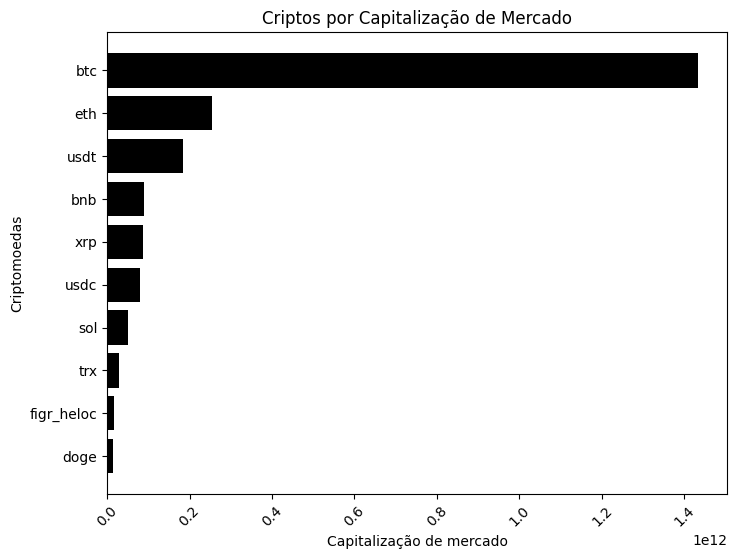

In [9]:
#vizualizações
plt.figure(figsize=(8,6))
plt.barh(top_cap.index,top_cap.values, color='black')
plt.gca().invert_yaxis()
plt.title('Criptos por Capitalização de Mercado')
plt.xlabel('Capitalização de mercado')
plt.ylabel('Criptomoedas')
plt.xticks(rotation=45)
plt.show()

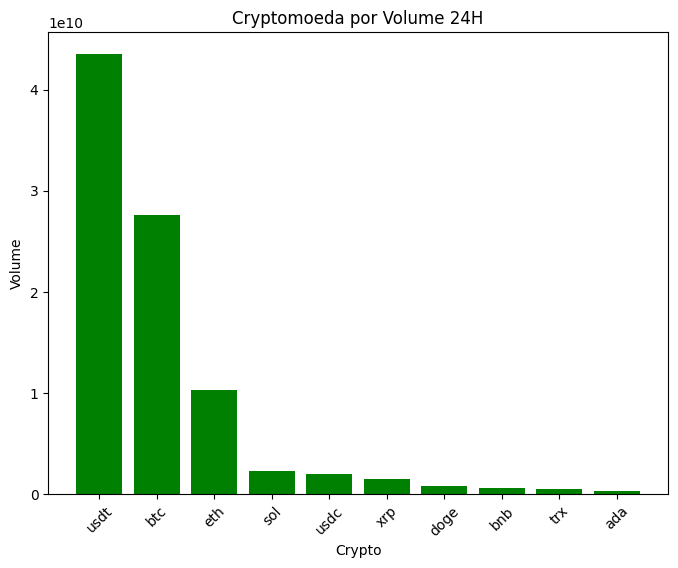

In [17]:
plt.figure(figsize=(8,6))
plt.bar(top_vol.index, top_vol.values, color='green')
plt.title('Cryptomoeda por Volume 24H')
plt.xlabel('Crypto')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.show()

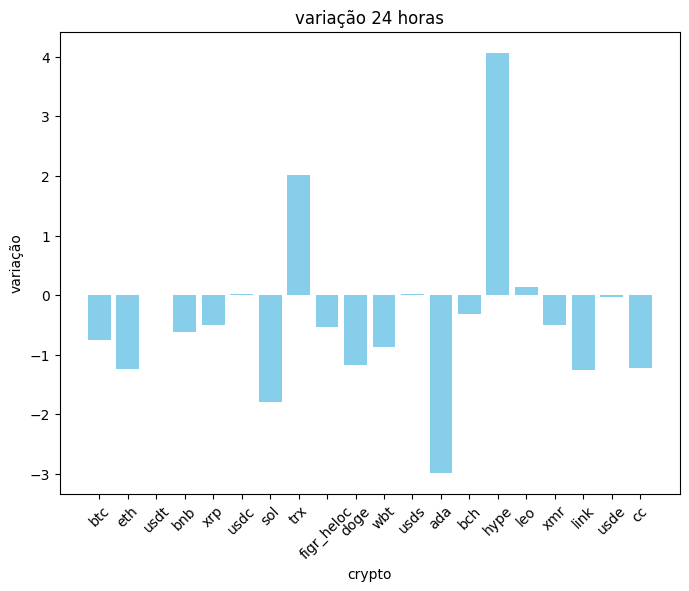

In [26]:
plt.figure(figsize=(8,6))
plt.bar(df['symbol'],df['price_change_percentage_24h'], color='skyblue')
plt.title('variação 24 horas')
plt.xlabel('crypto')
plt.ylabel('variação')
plt.xticks(rotation=45)
plt.show()